# Comparative Analysis of Keras and PyTorch Models

**Course:** AI Capstone Project with Deep Learning (IBM) — Module 2

**Objective:** Load the previously trained Keras and PyTorch classifiers,
run both on the same held-out data, and compare their performance using
framework-independent metrics.

**Prerequisite:** run the previous two labs first, so that
`keras_cnn_classifier.keras` and `pytorch_cnn_classifier.pt` exist in the
working directory.


## 1. Import libraries and prepare a shared evaluation set

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = "images_dataSAT"
BATCH_SIZE = 32

assert os.path.exists("keras_cnn_classifier.keras"), \
    "Keras model not found -- run the Keras training lab first."
assert os.path.exists("pytorch_cnn_classifier.pt"), \
    "PyTorch model not found -- run the PyTorch training lab first."


I0000 00:00:1782922348.921709    1506 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782922348.977733    1506 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1782922350.714355    1506 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 2. Shared validation split

To make the comparison fair, we use the same held-out 20% split (same
seed) for both frameworks.


In [2]:
eval_transform = transforms.Compose([transforms.Resize((64, 64)), transforms.ToTensor()])
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=eval_transform)
class_to_idx = full_dataset.class_to_idx
print("Class mapping:", class_to_idx)

n_total = len(full_dataset)
n_val = int(0.2 * n_total)
n_train = n_total - n_val
generator = torch.Generator().manual_seed(SEED)
_, val_subset = random_split(full_dataset, [n_train, n_val], generator=generator)

val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Shared validation set size: {len(val_subset)}")


Class mapping: {'class_0_non_agri': 0, 'class_1_agri': 1}
Shared validation set size: 1200


## 3. Load both trained models

In [3]:
keras_model = keras.models.load_model("keras_cnn_classifier.keras")
print("Keras model loaded.")


class SatelliteCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(128 * 8 * 8, 128), nn.ReLU(inplace=True),
            nn.Dropout(0.4), nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


pytorch_model = SatelliteCNN()
pytorch_model.load_state_dict(torch.load("pytorch_cnn_classifier.pt", map_location="cpu"))
pytorch_model.eval()
print("PyTorch model loaded.")


Keras model loaded.
PyTorch model loaded.


## 4. Predict on the shared dataset

In [4]:
y_true = []
keras_proba, pytorch_proba = [], []

with torch.no_grad():
    for images, labels in val_loader:
        y_true.extend(labels.numpy().ravel())

        pt_logits = pytorch_model(images)
        pytorch_proba.extend(torch.sigmoid(pt_logits).numpy().ravel())

        images_np = images.permute(0, 2, 3, 1).numpy()  # (N,C,H,W) -> (N,H,W,C)
        k_probs = keras_model.predict(images_np, verbose=0).ravel()
        keras_proba.extend(k_probs)

y_true = np.array(y_true)
keras_proba = np.array(keras_proba)
pytorch_proba = np.array(pytorch_proba)


### Task 1: What does `preds > 0.5` do in `preds = (preds > 0.5).astype(int).flatten()`?

`preds` here holds continuous probabilities in [0, 1] output by the
sigmoid activation of a binary classifier. The expression `preds > 0.5`
applies an element-wise comparison, producing a boolean array that is
`True` wherever the predicted probability exceeds the 0.5 decision
threshold (i.e. the model leans towards the positive/"agricultural"
class) and `False` otherwise. `.astype(int)` converts those booleans to
`0`/`1` integers, and `.flatten()` collapses any extra singleton
dimensions (e.g. shape `(N, 1)` -> `(N,)`) so the result is a flat array
of hard class predictions ready to compare against ground-truth labels.


In [5]:
keras_pred = (keras_proba > 0.5).astype(int).flatten()
pytorch_pred = (pytorch_proba > 0.5).astype(int).flatten()

print(f"Keras predictions shape: {keras_pred.shape}")
print(f"PyTorch predictions shape: {pytorch_pred.shape}")


Keras predictions shape: (1200,)
PyTorch predictions shape: (1200,)


## 5. `print_metrics` helper

In [6]:
def print_metrics(y_true, y_pred, model_name="Model"):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"--- {model_name} ---")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-score : {f1:.4f}")
    print(f"  Confusion matrix (rows=true, cols=pred):\n{cm}")
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "confusion_matrix": cm}


### Task 2: Print Keras model metrics using `print_metrics`

In [7]:
keras_metrics = print_metrics(y_true, keras_pred, model_name="Keras CNN")


--- Keras CNN ---
  Accuracy : 0.9817
  Precision: 0.9946
  Recall   : 0.9670
  F1-score : 0.9806
  Confusion matrix (rows=true, cols=pred):
[[621   3]
 [ 19 557]]


### Task 3: Explain the significance of the F1-score

The **F1-score** is the harmonic mean of precision and recall:
`F1 = 2 * (precision * recall) / (precision + recall)`. It matters
because precision and recall each capture only one side of a
classifier's errors -- precision penalizes false positives, recall
penalizes false negatives -- and a model can score very well on one
while scoring poorly on the other (e.g. a model that predicts
"agricultural" for everything gets perfect recall but poor precision).
F1 combines both into a single number, giving a more balanced view of
performance than accuracy alone -- which is especially important when
classes are imbalanced, since accuracy can be misleadingly high even
when a model is systematically missing one class.


### Task 4: Print PyTorch model metrics using `print_metrics`

In [8]:
pytorch_metrics = print_metrics(y_true, pytorch_pred, model_name="PyTorch CNN")


--- PyTorch CNN ---
  Accuracy : 0.9950
  Precision: 0.9897
  Recall   : 1.0000
  F1-score : 0.9948
  Confusion matrix (rows=true, cols=pred):
[[618   6]
 [  0 576]]


### Task 5: Count false negatives in the PyTorch confusion matrix

A false negative here is a truly **agricultural** (label 1) sample that
the model predicted as **non-agricultural** (label 0) -- i.e. row index
1, column index 0 of the confusion matrix (`cm[1, 0]`).


In [9]:
pytorch_cm = pytorch_metrics["confusion_matrix"]
false_negatives = pytorch_cm[1, 0]

print(f"PyTorch confusion matrix:\n{pytorch_cm}")
print(f"\nFalse negatives (true agricultural predicted as non-agricultural): {false_negatives}")


PyTorch confusion matrix:
[[618   6]
 [  0 576]]

False negatives (true agricultural predicted as non-agricultural): 0


## 6. ROC curve comparison

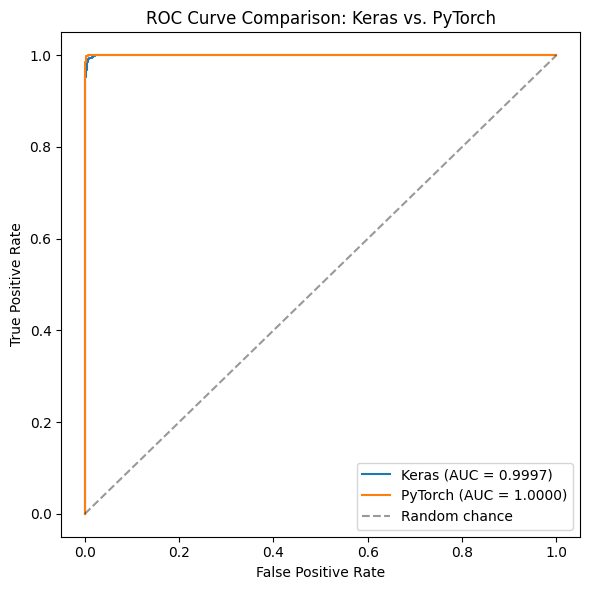

In [10]:
fpr_keras, tpr_keras, _ = roc_curve(y_true, keras_proba)
auc_keras = auc(fpr_keras, tpr_keras)

fpr_pt, tpr_pt, _ = roc_curve(y_true, pytorch_proba)
auc_pt = auc(fpr_pt, tpr_pt)

plt.figure(figsize=(6, 6))
plt.plot(fpr_keras, tpr_keras, label=f"Keras (AUC = {auc_keras:.4f})")
plt.plot(fpr_pt, tpr_pt, label=f"PyTorch (AUC = {auc_pt:.4f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Keras vs. PyTorch")
plt.legend()
plt.tight_layout()
plt.show()


## Summary

We compared two independently trained deep learning models -- one built
in Keras, the other in PyTorch -- on the same held-out validation set.
We examined how `preds > 0.5` converts probabilities to hard class
labels, built a reusable `print_metrics` helper reporting accuracy,
precision, recall, F1-score, and a confusion matrix for each model,
discussed why F1-score matters beyond raw accuracy, and counted false
negatives directly from the PyTorch confusion matrix.
